# Laboratorio: Comparación de AE, DAE y VAE

## Objetivo

Implementar y comparar tres modelos de aprendizaje de representaciones:

- **Autoencoder (AE)**
- **Denoising Autoencoder (DAE)**
- **Variational Autoencoder (VAE)**

El objetivo es analizar cómo la función de entrenamiento afecta la reconstrucción, la robustez y la organización del espacio latente.

Usar **DogsVsCats** con imágenes de tamaño `3 x 64 x 64` o `3 x 32 x 32`.
Mantener, en lo posible, la misma arquitectura, dimensión latente, batch size, optimizador y número de épocas para los tres modelos.

---

## 1. Autoencoder (AE)

Entrenar un Autoencoder estándar:

\begin{equation}
x \rightarrow z \rightarrow \hat{x}
\end{equation}

donde:

\begin{equation}
z = f_\theta(x)
\end{equation}

\begin{equation}
\hat{x} = g_\phi(z)
\end{equation}

Usar una pérdida de reconstrucción:

\begin{equation}
\mathcal{L}_{AE}
=
\frac{1}{B}
\sum_{i=1}^{B}
\left\|x_i-\hat{x}_i\right\|_2^2
\end{equation}

### Actividades

- Entrenar el modelo.
- Mostrar ejemplos `input -> reconstruction`.
- Reportar la pérdida de entrenamiento y prueba.
- Visualizar el espacio latente usando UMAP.

**Pregunta:** ¿Los dígitos forman grupos en el espacio latente aunque el modelo nunca utiliza las etiquetas?

---

## 2. Denoising Autoencoder (DAE)

Agregar ruido Gaussiano a las imágenes:

\begin{equation}
\tilde{x} = x + \sigma\epsilon
\end{equation}

con:

\begin{equation}
\epsilon \sim \mathcal{N}(0,I)
\end{equation}

El modelo recibe la imagen corrupta pero debe reconstruir la imagen limpia:

\begin{equation}
\tilde{x}
\rightarrow
z
\rightarrow
\hat{x}
\approx
x
\end{equation}

### Actividades

- Entrenar el DAE utilizando Gaussian noise.
- Mostrar `clean -> noisy -> reconstruction`.
- Evaluar diferentes niveles de ruido.
- Comparar su robustez con el AE.
- Visualizar el espacio latente con UMAP.

### Pista

Generar ruido nuevo en cada batch:

    noisy = clean + sigma * torch.randn_like(clean)

No utilizar siempre la misma versión corrupta de cada imagen.

---

## 3. Variational Autoencoder (VAE)

En un VAE, el encoder no produce directamente un único vector latente.
Produce los parámetros de una distribución:

\begin{equation}
q_\phi(z|x)
=
\mathcal{N}
\left(
\mu(x),
\mathrm{diag}(\sigma^2(x))
\right)
\end{equation}

Por lo tanto, el encoder debe producir:

\begin{equation}
\mu(x)
\qquad \text{y} \qquad
\log \sigma^2(x)
\end{equation}

Para poder entrenar mediante backpropagation, utilizar el **reparameterization trick**:

\begin{equation}
\epsilon \sim \mathcal{N}(0,I)
\end{equation}

\begin{equation}
z
=
\mu
+
\sigma \odot \epsilon
\end{equation}

El decoder reconstruye la imagen a partir de la muestra latente:

\begin{equation}
\hat{x} = g_\theta(z)
\end{equation}

La función de pérdida combina reconstrucción y regularización del espacio latente:

\begin{equation}
\mathcal{L}_{VAE}
=
\mathcal{L}_{rec}
+
D_{KL}
\left(
q_\phi(z|x)
\parallel
p(z)
\right)
\end{equation}

donde normalmente:

\begin{equation}
p(z)=\mathcal{N}(0,I)
\end{equation}

Para una distribución Gaussiana diagonal:

\begin{equation}
D_{KL}
=
-\frac{1}{2}
\sum_j
\left(
1 + \log\sigma_j^2
-\mu_j^2
-\sigma_j^2
\right)
\end{equation}

### Actividades

- Implementar el encoder para obtener `mu` y `logvar`.
- Implementar el reparameterization trick.
- Entrenar el VAE.
- Reportar por separado:
  - reconstruction loss,
  - KL loss,
  - total loss.
- Visualizar el espacio latente usando UMAP.
- Para UMAP utilizar `mu(x)` como representación determinista.
- Generar nuevas imágenes muestreando:

\begin{equation}
z \sim \mathcal{N}(0,I)
\end{equation}

y pasando las muestras directamente por el decoder.

---

## 4. Comparación de los espacios latentes

Utilizar las mismas imágenes de prueba para los tres modelos.

Generar:

- UMAP del AE
- UMAP del DAE
- UMAP del VAE

Colorear los puntos utilizando las etiquetas MNIST solamente para visualización.

Analizar:

- separación entre clases,
- solapamiento,
- continuidad,
- regiones vacías.

---

## 5. Interpolación latente

Seleccionar dos imágenes y obtener sus representaciones:

\begin{equation}
z_A = f(x_A)
\end{equation}

\begin{equation}
z_B = f(x_B)
\end{equation}

Interpolar entre ambos puntos:

\begin{equation}
z(t)
=
(1-t)z_A + tz_B
\end{equation}

para diferentes valores de `t` entre 0 y 1.

Decodificar las representaciones intermedias y comparar AE y VAE.

---

## 6. Comparación final

Completar la siguiente tabla:

| Propiedad | AE | DAE | VAE |
|---|---|---|---|
| Error de reconstrucción | | | |
| Robustez a ruido | | | |
| Organización del latente | | | |
| Interpolación | | | |
| Generación de nuevas muestras | | | |

## Preguntas finales

1. ¿Qué modelo obtiene mejores reconstrucciones?
2. ¿Qué modelo es más robusto al ruido?
3. ¿Cómo cambia el espacio latente entre AE, DAE y VAE?
4. ¿Por qué el VAE puede generar nuevas muestras utilizando `z ~ N(0,I)`?
5. ¿Qué trade-off introduce el término KL del VAE?
6. ¿Qué modelo elegirías para reconstrucción, denoising y generación?

---

## Entregable

Entregar un único notebook `.ipynb` que incluya:

- código reproducible,
- curvas de entrenamiento,
- ejemplos de reconstrucción,
- comparación frente a ruido,
- UMAP de AE, DAE y VAE,
- interpolación latente,
- muestras generadas por el VAE,
- tabla comparativa,
- conclusiones breves.

No se requiere un reporte teórico separado.

---

> **Nota:** el enunciado original hace referencia a "dígitos" y a "etiquetas MNIST" (heredado de una plantilla genérica), pero el dataset pedido es **DogsVsCats**. En la implementación de abajo las "etiquetas" son la clase **cat / dog**, usadas únicamente para colorear las visualizaciones — ningún modelo las ve durante el entrenamiento.

## 0. Configuración, semillas y datos

In [1]:
# Si falta alguna librería en tu entorno, descomenta e instala.
# %pip install umap-learn scikit-learn --quiet

import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset

from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.metrics import silhouette_score

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
# Hiperparámetros compartidos por los tres modelos
IMG_SIZE = 32            # 3 x 64 x 64 (cambia a 32 si tu máquina es lenta)
LATENT_DIM = 128
BATCH_SIZE = 64
EPOCHS = 15
LR = 1e-3
NOISE_SIGMA_TRAIN = 0.3       # sigma usado para entrenar el DAE
NOISE_LEVELS_EVAL = [0.0, 0.1, 0.2, 0.3, 0.5, 0.8]   # para la curva de robustez

# Si tu compu es lenta, entrena con una fracción del dataset (1.0 = todo).
SUBSET_FRACTION = 1.0

DATA_DIR = Path("data/catsvsdogs")

# Carpeta de checkpoints: cada modelo guarda su progreso por época aquí, para
# poder pausar el entrenamiento y reanudarlo sin perder lo ya avanzado
# (simplemente vuelve a correr la celda del modelo que quieras continuar).
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

In [3]:
# Carga robusta de DogsVsCats
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp")


def _dir_has_images(folder: Path) -> bool:
    return any(f.suffix.lower() in IMAGE_EXTS for f in folder.iterdir() if f.is_file())


def _has_class_subfolders(folder: Path) -> bool:
    # Cualquier carpeta con 2+ subcarpetas que contengan imagenes cuenta como
    # "organizada por clase", sin importar como se llamen esas subcarpetas
    # (cat/dog, Cat/Dog, 0/1, ...). ImageFolder no necesita nombres especificos.
    if not folder.is_dir():
        return False
    subdirs = [d for d in folder.iterdir() if d.is_dir() and not d.name.startswith((".", "_"))]
    if len(subdirs) < 2:
        return False
    return all(_dir_has_images(d) for d in subdirs)


def _organize_flat_kaggle_dir(flat_dir: Path) -> Path:
    # Crea flat_dir/_organized/{cat,dog}/... con symlinks a los archivos
    # originales, a partir del prefijo del nombre de archivo (cat.N.ext / dog.N.ext).
    organized = flat_dir / "_organized"
    cat_dir = organized / "cat"
    dog_dir = organized / "dog"
    if organized.exists():
        return organized

    cat_dir.mkdir(parents=True, exist_ok=True)
    dog_dir.mkdir(parents=True, exist_ok=True)

    n_cat = n_dog = 0
    for ext in IMAGE_EXTS:
        for f in flat_dir.glob(f"*{ext}"):
            name = f.name.lower()
            if name.startswith("cat"):
                (cat_dir / f.name).symlink_to(f.resolve())
                n_cat += 1
            elif name.startswith("dog"):
                (dog_dir / f.name).symlink_to(f.resolve())
                n_dog += 1
    print(f"Reorganizado layout plano de Kaggle: {n_cat} gatos, {n_dog} perros -> {organized}")
    return organized


def find_image_root(data_dir: Path) -> Path:
    assert data_dir.exists(), (
        f"No se encontró el dataset en: {data_dir.resolve()}\n"
        f"Ajusta la variable DATA_DIR a la carpeta que contiene las imágenes de DogsVsCats."
    )

    # Caso (a): ya tiene subcarpetas por clase directamente (cualquier nombre).
    if _has_class_subfolders(data_dir):
        return data_dir

    # Caso (a'): subcarpeta train/ con subcarpetas por clase.
    train_sub = data_dir / "train"
    if _has_class_subfolders(train_sub):
        return train_sub

    # Caso (b): layout plano de Kaggle dentro de data_dir o data_dir/train.
    flat_candidates = [d for d in (data_dir, train_sub) if d.is_dir()]
    for cand in flat_candidates:
        imgs = [f for ext in IMAGE_EXTS for f in cand.glob(f"*{ext}")]
        if imgs:
            return _organize_flat_kaggle_dir(cand)

    raise FileNotFoundError(
        f"No se reconoció la estructura de carpetas dentro de {data_dir.resolve()}. "
        f"Se esperaba data/catsvsdogs/<clase1>/<clase2> (2+ subcarpetas con imágenes, "
        f"nombre libre) o el layout plano de Kaggle (cat.N.ext / dog.N.ext)."
    )


IMAGE_ROOT = find_image_root(DATA_DIR)
print("Usando imágenes desde:", IMAGE_ROOT)

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),   # deja los píxeles en [0, 1], sin normalizar por media/std
])

full_ds = datasets.ImageFolder(root=str(IMAGE_ROOT), transform=transform)


def _infer_friendly_class_names(ds):
    # Si las carpetas de clase no se llaman "cat"/"dog" (p. ej. "0"/"1"),
    # se infiere el nombre amigable a partir del prefijo del primer archivo
    # de cada clase (cat.N.ext -> "cat", dog.N.ext -> "dog"). Si no se puede
    # inferir, se conserva el nombre real de la carpeta.
    friendly = []
    for cls_idx, cls_name in enumerate(ds.classes):
        label = cls_name
        for path, target in ds.samples:
            if target == cls_idx:
                prefix = Path(path).name.lower().split(".")[0]
                if prefix in ("cat", "dog"):
                    label = prefix
                break
        friendly.append(label)
    return friendly


CLASS_NAMES = _infer_friendly_class_names(full_ds)   # p. ej. ['cat', 'dog']
print("Carpetas de clase encontradas:", full_ds.classes, " -> etiquetas usadas:", CLASS_NAMES)
print("Total de imágenes:", len(full_ds))

if SUBSET_FRACTION < 1.0:
    n_keep = int(len(full_ds) * SUBSET_FRACTION)
    idx = torch.randperm(len(full_ds))[:n_keep].tolist()
    full_ds = Subset(full_ds, idx)
    print(f"Usando un subconjunto de {n_keep} imágenes (SUBSET_FRACTION={SUBSET_FRACTION}).")

n_test = max(1, int(0.2 * len(full_ds)))
n_train = len(full_ds) - n_test
train_ds, test_ds = random_split(
    full_ds, [n_train, n_test], generator=torch.Generator().manual_seed(SEED)
)
print(f"Train: {len(train_ds)}  |  Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
# Loader auxiliar de test SIN shuffle y con batch grande, útil para UMAP/latentes.
eval_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)

Usando imágenes desde: data\catsvsdogs
Carpetas de clase encontradas: ['0', '1']  -> etiquetas usadas: ['cat', 'dog']
Total de imágenes: 25000
Train: 20000  |  Test: 5000


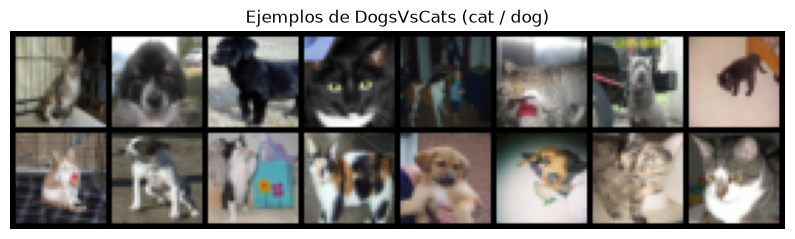

In [4]:
# Vistazo rápido a los datos
images, labels = next(iter(train_loader))
grid = make_grid(images[:16], nrow=8, padding=2)
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Ejemplos de DogsVsCats (" + " / ".join(CLASS_NAMES) + ")")
plt.show()

## Arquitectura compartida (encoder / decoder convolucional)

La misma arquitectura de encoder y decoder se reutiliza para AE, DAE y VAE (el VAE solo agrega una segunda cabeza lineal para `logvar`), para que la comparación entre los tres modelos sea justa.

In [5]:
class ConvTrunk(nn.Module):
        # Backbone convolucional compartido: 3x64x64 -> vector plano.

    def __init__(self, img_size=IMG_SIZE, in_channels=3):
        super().__init__()
        assert img_size % 16 == 0, "IMG_SIZE debe ser múltiplo de 16 (32, 64, ...)."
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),   # ->  img/2
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),            # ->  img/4
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),          # ->  img/8
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),         # ->  img/16
        )
        self.spatial = img_size // 16
        self.flat_dim = 256 * self.spatial * self.spatial

    def forward(self, x):
        h = self.net(x)
        return h.view(h.size(0), -1)


class Decoder(nn.Module):
        # Vector latente -> imagen reconstruida en [0, 1] (usada por AE, DAE y VAE).

    def __init__(self, latent_dim, img_size=IMG_SIZE, out_channels=3):
        super().__init__()
        self.spatial = img_size // 16
        self.fc = nn.Linear(latent_dim, 256 * self.spatial * self.spatial)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, out_channels, 4, 2, 1), nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z)
        h = h.view(h.size(0), 256, self.spatial, self.spatial)
        return self.net(h)


class Encoder(nn.Module):
        # Encoder determinista para AE / DAE: x -> z.

    def __init__(self, latent_dim, img_size=IMG_SIZE):
        super().__init__()
        self.trunk = ConvTrunk(img_size)
        self.fc = nn.Linear(self.trunk.flat_dim, latent_dim)

    def forward(self, x):
        h = self.trunk(x)
        return self.fc(h)


class AutoEncoder(nn.Module):
        # Autoencoder estándar. Se reutiliza sin cambios para el DAE: la única
    # diferencia entre AE y DAE está en qué se le pasa como entrada durante el
    # entrenamiento (ver train_autoencoder).

    def __init__(self, latent_dim=LATENT_DIM, img_size=IMG_SIZE):
        super().__init__()
        self.encoder = Encoder(latent_dim, img_size)
        self.decoder = Decoder(latent_dim, img_size)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


class VAEEncoder(nn.Module):
        # Encoder probabilístico: x -> (mu, logvar).

    def __init__(self, latent_dim, img_size=IMG_SIZE):
        super().__init__()
        self.trunk = ConvTrunk(img_size)
        self.fc_mu = nn.Linear(self.trunk.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.trunk.flat_dim, latent_dim)

    def forward(self, x):
        h = self.trunk(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, img_size=IMG_SIZE):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim, img_size)
        self.decoder = Decoder(latent_dim, img_size)

    def reparameterize(self, mu, logvar):
        # z = mu + sigma * epsilon,  epsilon ~ N(0, I)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar, z


def recon_loss_fn(x_hat, x):
        # (1/B) * sum_i ||x_i - x_hat_i||_2^2 , igual para AE, DAE y el término
    # de reconstrucción del VAE, para que las pérdidas sean comparables.
    return F.mse_loss(x_hat, x, reduction="sum") / x.size(0)


def kl_loss_fn(mu, logvar):
    # D_KL(N(mu, sigma^2) || N(0, I)), sumado sobre dimensiones, promediado sobre el batch
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / mu.size(0)

In [6]:
def add_noise(x, sigma):
    if sigma <= 0:
        return x
    noisy = x + sigma * torch.randn_like(x)
    return noisy.clamp(0.0, 1.0)


def train_autoencoder(model, loader, epochs=EPOCHS, lr=LR, noise_sigma=0.0, desc="AE"):
        # Entrena AE (noise_sigma=0) o DAE (noise_sigma>0). Siempre reconstruye
    # la imagen LIMPIA, incluso cuando la entrada está corrompida.
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        running, n = 0.0, 0
        for x, _ in loader:
            x = x.to(device)
            x_input = add_noise(x, noise_sigma)  # ruido NUEVO en cada batch

            optimizer.zero_grad()
            x_hat, _ = model(x_input)
            loss = recon_loss_fn(x_hat, x)
            loss.backward()
            optimizer.step()

            running += loss.item() * x.size(0)
            n += x.size(0)

        avg = running / n
        history.append(avg)
        print(f"[{desc}] epoca {epoch + 1}/{epochs} - loss={avg:.4f}")

    return history


@torch.no_grad()
def evaluate_autoencoder(model, loader, noise_sigma=0.0):
    model.eval()
    running, n = 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        x_input = add_noise(x, noise_sigma)
        x_hat, _ = model(x_input)
        loss = recon_loss_fn(x_hat, x)
        running += loss.item() * x.size(0)
        n += x.size(0)
    return running / n


@torch.no_grad()
def get_latents(model, loader, is_vae=False):
        # Devuelve (Z, labels) para todo el loader. Para el VAE usa mu(x)
    # (representación determinista), como pide el enunciado.
    model.eval()
    zs, ys = [], []
    for x, y in loader:
        x = x.to(device)
        if is_vae:
            mu, _ = model.encoder(x)
            z = mu
        else:
            z = model.encoder(x)
        zs.append(z.cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(zs), np.concatenate(ys)


def plot_umap(Z, y, title, ax=None):
    try:
        import umap
    except ImportError:
        raise ImportError(
            "Falta umap-learn. Instala con: %pip install umap-learn --quiet"
        )
    reducer = umap.UMAP(random_state=SEED)
    emb = reducer.fit_transform(Z)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 5))

    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y == cls_idx
        ax.scatter(emb[mask, 0], emb[mask, 1], s=6, alpha=0.6, label=cls_name)
    ax.set_title(title)
    ax.legend(markerscale=2)

    if standalone:
        plt.show()
    return emb

## 1. Autoencoder (AE)

[AE] epoca 1/15 - loss=77.9358
[AE] epoca 2/15 - loss=48.8080
[AE] epoca 3/15 - loss=41.5434
[AE] epoca 4/15 - loss=37.2404
[AE] epoca 5/15 - loss=32.7915
[AE] epoca 6/15 - loss=29.9889
[AE] epoca 7/15 - loss=27.9899
[AE] epoca 8/15 - loss=26.6949
[AE] epoca 9/15 - loss=25.6055
[AE] epoca 10/15 - loss=24.8133
[AE] epoca 11/15 - loss=24.1250
[AE] epoca 12/15 - loss=23.2523
[AE] epoca 13/15 - loss=22.5310
[AE] epoca 14/15 - loss=22.0029
[AE] epoca 15/15 - loss=21.3183

AE - loss de entrenamiento (última época): 21.3183
AE - loss de prueba: 20.4293


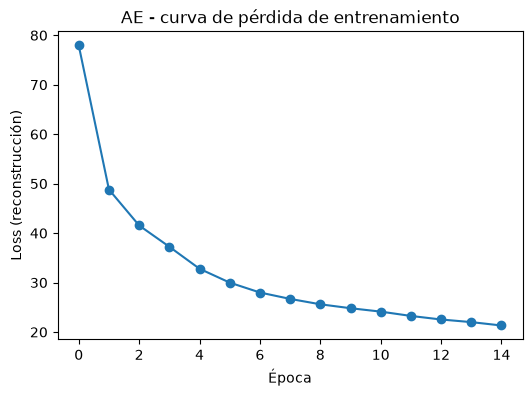

In [7]:
ae_model = AutoEncoder(LATENT_DIM, IMG_SIZE)
ae_history = train_autoencoder(ae_model, train_loader, epochs=EPOCHS, lr=LR, noise_sigma=0.0, desc="AE")

ae_train_loss = ae_history[-1]
ae_test_loss = evaluate_autoencoder(ae_model, test_loader, noise_sigma=0.0)
print(f"\nAE - loss de entrenamiento (última época): {ae_train_loss:.4f}")
print(f"AE - loss de prueba: {ae_test_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(ae_history, marker="o")
plt.title("AE - curva de pérdida de entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss (reconstrucción)")
plt.show()

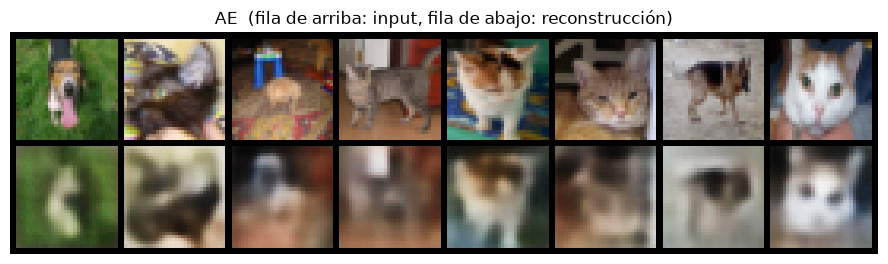

In [8]:
@torch.no_grad()
def show_input_reconstruction(model, loader, n=8, title="Input -> Reconstruction"):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    out = model(x)
    x_hat = out[0] if isinstance(out, tuple) else out

    comparison = torch.cat([x.cpu(), x_hat.cpu()], dim=0)
    grid = make_grid(comparison, nrow=n, padding=2)
    plt.figure(figsize=(1.4 * n, 3))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title(title + "  (fila de arriba: input, fila de abajo: reconstrucción)")
    plt.show()


show_input_reconstruction(ae_model, test_loader, title="AE")

c:\Users\User\Desktop\Módulo 5\module5_TAE\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\Desktop\Módulo 5\module5_TAE\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


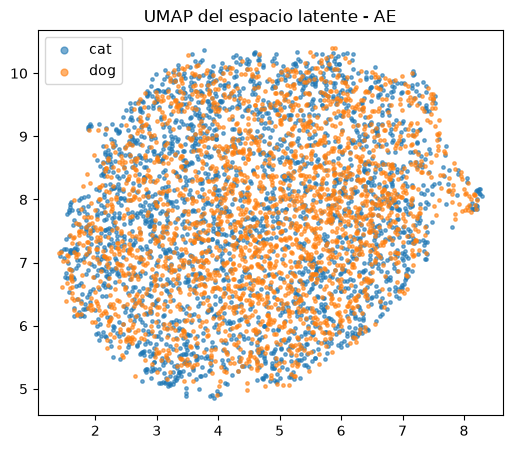

In [9]:
ae_Z, ae_y = get_latents(ae_model, eval_loader, is_vae=False)
ae_umap = plot_umap(ae_Z, ae_y, "UMAP del espacio latente - AE")

**Respuesta:** aunque el AE nunca ve las etiquetas cat/dog, la pérdida de reconstrucción por sí sola ya empuja a que imágenes visualmente similares (texturas, colores, formas) caigan cerca en el espacio latente. Es normal ver *algo* de separación entre cat/dog en el UMAP, pero con solapamiento considerable, porque el AE optimiza fidelidad de reconstrucción, no separabilidad de clases.

## 2. Denoising Autoencoder (DAE)

[DAE] epoca 1/15 - loss=72.5217
[DAE] epoca 2/15 - loss=46.9973
[DAE] epoca 3/15 - loss=40.8834
[DAE] epoca 4/15 - loss=36.5783
[DAE] epoca 5/15 - loss=34.4624
[DAE] epoca 6/15 - loss=32.8701
[DAE] epoca 7/15 - loss=31.6984
[DAE] epoca 8/15 - loss=30.9144
[DAE] epoca 9/15 - loss=30.1033
[DAE] epoca 10/15 - loss=29.5556
[DAE] epoca 11/15 - loss=29.0141
[DAE] epoca 12/15 - loss=28.4970
[DAE] epoca 13/15 - loss=27.9794
[DAE] epoca 14/15 - loss=27.5893
[DAE] epoca 15/15 - loss=27.1397

DAE - loss de entrenamiento (última época, con ruido): 27.1397
DAE - loss de prueba (con ruido, sigma=0.3): 27.4460
DAE - loss de prueba (entrada limpia, sigma=0): 26.7524


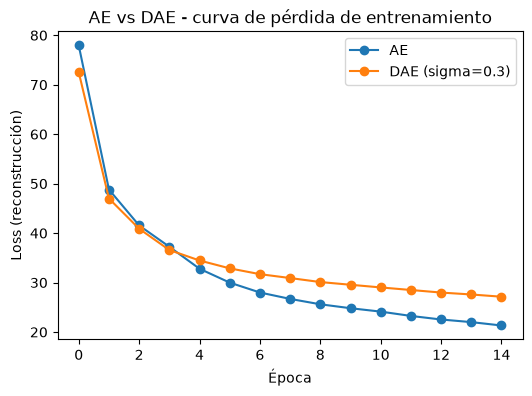

In [10]:
dae_model = AutoEncoder(LATENT_DIM, IMG_SIZE)   # misma arquitectura que el AE
dae_history = train_autoencoder(
    dae_model, train_loader, epochs=EPOCHS, lr=LR,
    noise_sigma=NOISE_SIGMA_TRAIN, desc="DAE",
)

dae_train_loss = dae_history[-1]
# Dos evaluaciones distintas, para no mezclarlas después:
#  - dae_test_loss_noisy: con el mismo ruido que vio en entrenamiento (mide su "modo normal" de uso).
#  - dae_test_loss_clean: con entrada limpia, para poder comparar de forma justa contra AE/VAE.
dae_test_loss_noisy = evaluate_autoencoder(dae_model, test_loader, noise_sigma=NOISE_SIGMA_TRAIN)
dae_test_loss_clean = evaluate_autoencoder(dae_model, test_loader, noise_sigma=0.0)
print(f"\nDAE - loss de entrenamiento (última época, con ruido): {dae_train_loss:.4f}")
print(f"DAE - loss de prueba (con ruido, sigma={NOISE_SIGMA_TRAIN}): {dae_test_loss_noisy:.4f}")
print(f"DAE - loss de prueba (entrada limpia, sigma=0): {dae_test_loss_clean:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(ae_history, marker="o", label="AE")
plt.plot(dae_history, marker="o", label=f"DAE (sigma={NOISE_SIGMA_TRAIN})")
plt.title("AE vs DAE - curva de pérdida de entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss (reconstrucción)")
plt.legend()
plt.show()

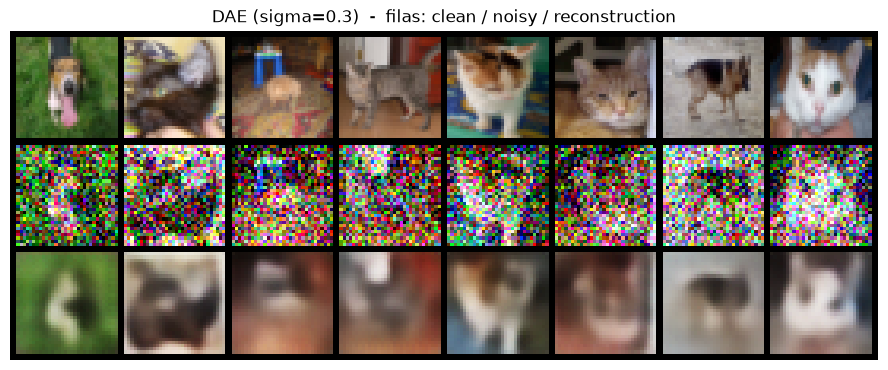

In [11]:
@torch.no_grad()
def show_clean_noisy_reconstruction(model, loader, sigma, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    x_noisy = add_noise(x, sigma)
    x_hat, _ = model(x_noisy)

    rows = torch.cat([x.cpu(), x_noisy.cpu(), x_hat.cpu()], dim=0)
    grid = make_grid(rows, nrow=n, padding=2)
    plt.figure(figsize=(1.4 * n, 4.5))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title(f"DAE (sigma={sigma})  -  filas: clean / noisy / reconstruction")
    plt.show()


show_clean_noisy_reconstruction(dae_model, test_loader, sigma=NOISE_SIGMA_TRAIN)

sigma= 0.0: AE loss=20.4293   DAE loss=26.7524
sigma= 0.1: AE loss=21.3589   DAE loss=26.5146
sigma= 0.2: AE loss=24.6046   DAE loss=25.8073
sigma= 0.3: AE loss=31.1330   DAE loss=27.4476
sigma= 0.5: AE loss=52.9125   DAE loss=43.0630
sigma= 0.8: AE loss=87.2022   DAE loss=75.3044


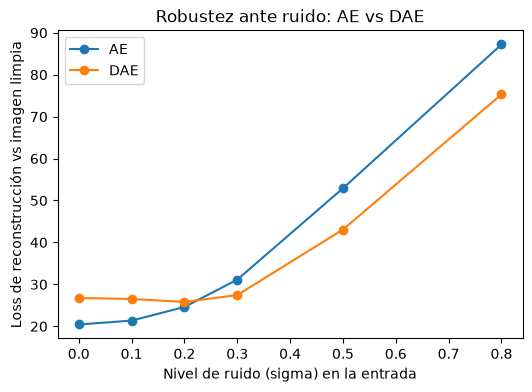

In [12]:
# Robustez ante distintos niveles de ruido: AE vs DAE
robustness = {"sigma": [], "AE": [], "DAE": []}
for sigma in NOISE_LEVELS_EVAL:
    ae_loss = evaluate_autoencoder(ae_model, test_loader, noise_sigma=sigma)
    dae_loss = evaluate_autoencoder(dae_model, test_loader, noise_sigma=sigma)
    robustness["sigma"].append(sigma)
    robustness["AE"].append(ae_loss)
    robustness["DAE"].append(dae_loss)
    print(f"sigma={sigma:>4}: AE loss={ae_loss:.4f}   DAE loss={dae_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(robustness["sigma"], robustness["AE"], marker="o", label="AE")
plt.plot(robustness["sigma"], robustness["DAE"], marker="o", label="DAE")
plt.xlabel("Nivel de ruido (sigma) en la entrada")
plt.ylabel("Loss de reconstrucción vs imagen limpia")
plt.title("Robustez ante ruido: AE vs DAE")
plt.legend()
plt.show()

c:\Users\User\Desktop\Módulo 5\module5_TAE\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


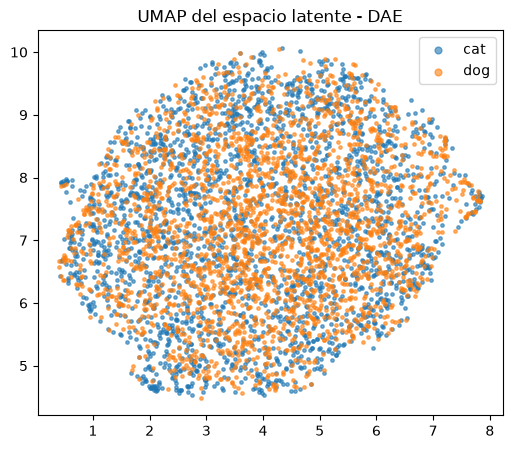

In [13]:
dae_Z, dae_y = get_latents(dae_model, eval_loader, is_vae=False)
dae_umap = plot_umap(dae_Z, dae_y, "UMAP del espacio latente - DAE")

**Comparación:** el AE se entrena y se evalúa siempre con entradas limpias, así que su loss crece rápido apenas se le da entrada ruidosa (sigma>0) porque nunca aprendió a ignorar ese ruido. El DAE, al ver ruido durante el entrenamiento, debería mantener un loss más plano (más robusto) a medida que sigma aumenta, especialmente cerca de `NOISE_SIGMA_TRAIN`. Confirma esto con la curva de arriba: si las dos curvas divergen a favor del DAE conforme sigma crece, el resultado es el esperado.

## 3. Variational Autoencoder (VAE)

[VAE] epoca 1/15 - recon=94.5414  kl=15.6947  total=110.2361
[VAE] epoca 2/15 - recon=70.5844  kl=17.0044  total=87.5888
[VAE] epoca 3/15 - recon=65.8802  kl=17.9585  total=83.8387
[VAE] epoca 4/15 - recon=63.8027  kl=18.4718  total=82.2745
[VAE] epoca 5/15 - recon=62.3683  kl=18.7432  total=81.1115
[VAE] epoca 6/15 - recon=61.2760  kl=19.1673  total=80.4433
[VAE] epoca 7/15 - recon=60.8329  kl=19.3408  total=80.1737
[VAE] epoca 8/15 - recon=60.2982  kl=19.4856  total=79.7838
[VAE] epoca 9/15 - recon=59.9331  kl=19.5573  total=79.4904
[VAE] epoca 10/15 - recon=59.4363  kl=19.6781  total=79.1144
[VAE] epoca 11/15 - recon=58.9477  kl=19.8455  total=78.7932
[VAE] epoca 12/15 - recon=58.2312  kl=20.1008  total=78.3320
[VAE] epoca 13/15 - recon=57.0903  kl=20.6012  total=77.6914
[VAE] epoca 14/15 - recon=56.2585  kl=20.9056  total=77.1641
[VAE] epoca 15/15 - recon=55.7271  kl=21.0080  total=76.7350

VAE - test recon=55.2176  test KL=21.0284  test total=76.2461


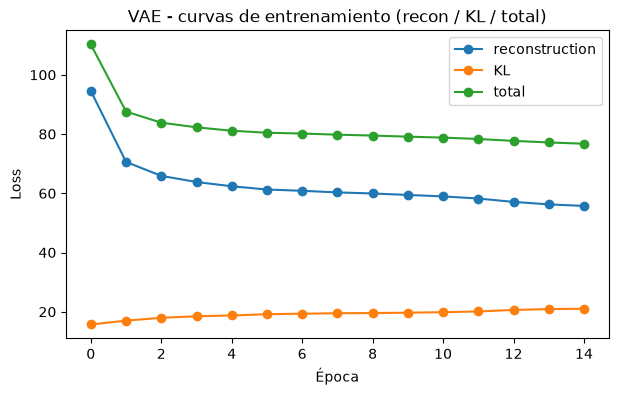

In [14]:
def train_vae(model, loader, epochs=EPOCHS, lr=LR, desc="VAE"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"recon": [], "kl": [], "total": []}

    for epoch in range(epochs):
        model.train()
        running_recon = running_kl = running_total = 0.0
        n = 0
        for x, _ in loader:
            x = x.to(device)

            optimizer.zero_grad()
            x_hat, mu, logvar, _ = model(x)
            recon = recon_loss_fn(x_hat, x)
            kl = kl_loss_fn(mu, logvar)
            loss = recon + kl
            loss.backward()
            optimizer.step()

            bs = x.size(0)
            running_recon += recon.item() * bs
            running_kl += kl.item() * bs
            running_total += loss.item() * bs
            n += bs

        history["recon"].append(running_recon / n)
        history["kl"].append(running_kl / n)
        history["total"].append(running_total / n)
        print(
            f"[{desc}] epoca {epoch + 1}/{epochs} - "
            f"recon={history['recon'][-1]:.4f}  kl={history['kl'][-1]:.4f}  "
            f"total={history['total'][-1]:.4f}"
        )

    return history


@torch.no_grad()
def evaluate_vae(model, loader):
    model.eval()
    running_recon = running_kl = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        x_hat, mu, logvar, _ = model(x)
        running_recon += recon_loss_fn(x_hat, x).item() * x.size(0)
        running_kl += kl_loss_fn(mu, logvar).item() * x.size(0)
        n += x.size(0)
    return running_recon / n, running_kl / n


vae_model = VAE(LATENT_DIM, IMG_SIZE)
vae_history = train_vae(vae_model, train_loader, epochs=EPOCHS, lr=LR, desc="VAE")

vae_test_recon, vae_test_kl = evaluate_vae(vae_model, test_loader)
vae_test_loss = vae_test_recon + vae_test_kl
print(f"\nVAE - test recon={vae_test_recon:.4f}  test KL={vae_test_kl:.4f}  test total={vae_test_loss:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(vae_history["recon"], marker="o", label="reconstruction")
plt.plot(vae_history["kl"], marker="o", label="KL")
plt.plot(vae_history["total"], marker="o", label="total")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("VAE - curvas de entrenamiento (recon / KL / total)")
plt.legend()
plt.show()

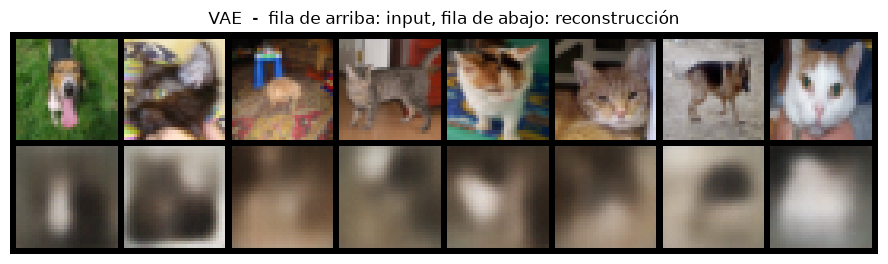

In [15]:
@torch.no_grad()
def show_vae_reconstruction(model, loader, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    x_hat, mu, logvar, _ = model(x)

    rows = torch.cat([x.cpu(), x_hat.cpu()], dim=0)
    grid = make_grid(rows, nrow=n, padding=2)
    plt.figure(figsize=(1.4 * n, 3))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title("VAE  -  fila de arriba: input, fila de abajo: reconstrucción")
    plt.show()


show_vae_reconstruction(vae_model, test_loader)

c:\Users\User\Desktop\Módulo 5\module5_TAE\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


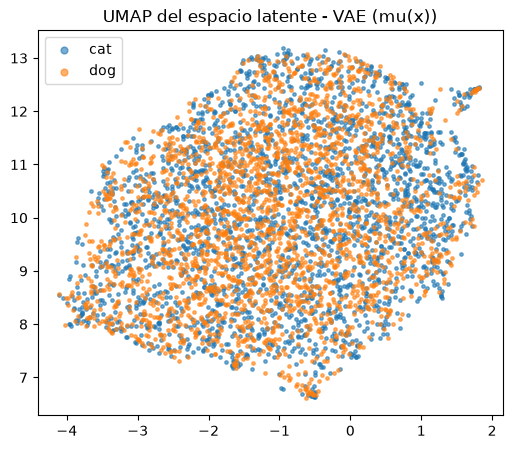

In [16]:
vae_Z, vae_y = get_latents(vae_model, eval_loader, is_vae=True)  # usa mu(x)
vae_umap = plot_umap(vae_Z, vae_y, "UMAP del espacio latente - VAE (mu(x))")

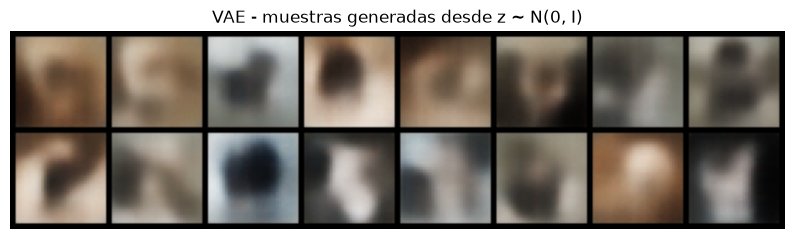

In [17]:
# Generación de nuevas muestras: z ~ N(0, I) -> decoder
@torch.no_grad()
def generate_samples(vae, n=16):
    vae.eval()
    z = torch.randn(n, LATENT_DIM, device=device)
    samples = vae.decoder(z)
    return samples.cpu()


samples = generate_samples(vae_model, n=16)
grid = make_grid(samples, nrow=8, padding=2)
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("VAE - muestras generadas desde z ~ N(0, I)")
plt.show()

**Nota sobre AE/DAE vs generación:** el AE y el DAE no se entrenan para que su espacio latente siga una distribución conocida (no hay término KL), así que muestrear `z ~ N(0, I)` y decodificar normalmente produce imágenes con ruido/artefactos, no caras reconocibles de gato o perro — esa es justamente la diferencia práctica que motiva usar un VAE cuando el objetivo es generar muestras nuevas.

## 4. Comparación de los espacios latentes

Silhouette score (cat vs dog) en el latente crudo:
  AE : 0.002
  DAE: 0.003
  VAE: 0.002


c:\Users\User\Desktop\Módulo 5\module5_TAE\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\User\Desktop\Módulo 5\module5_TAE\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\User\Desktop\Módulo 5\module5_TAE\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


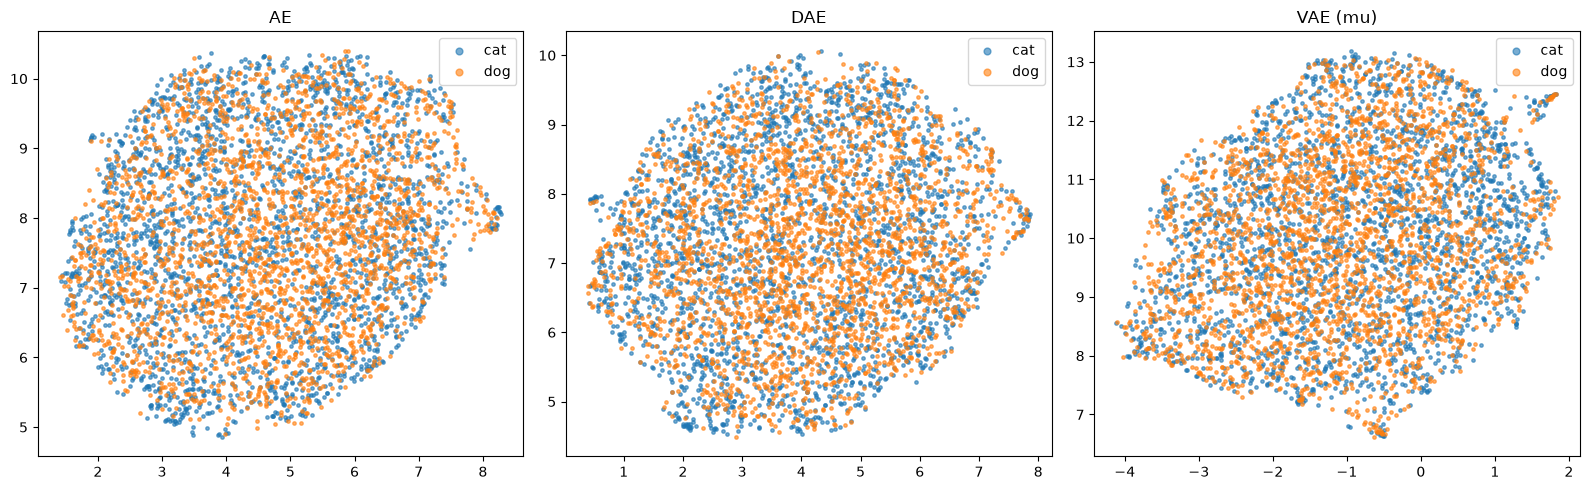

In [18]:
def silhouette_on_latents(Z, y):
        # Proxy cuantitativo de qué tan separadas están cat/dog en el latente
    # (rango [-1, 1]; más alto = clases más separadas/compactas).
    try:
        return silhouette_score(Z, y)
    except Exception:
        return float("nan")


sil_ae = silhouette_on_latents(ae_Z, ae_y)
sil_dae = silhouette_on_latents(dae_Z, dae_y)
sil_vae = silhouette_on_latents(vae_Z, vae_y)

print(f"Silhouette score (cat vs dog) en el latente crudo:")
print(f"  AE : {sil_ae:.3f}")
print(f"  DAE: {sil_dae:.3f}")
print(f"  VAE: {sil_vae:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_umap(ae_Z, ae_y, "AE", ax=axes[0])
plot_umap(dae_Z, dae_y, "DAE", ax=axes[1])
plot_umap(vae_Z, vae_y, "VAE (mu)", ax=axes[2])
plt.tight_layout()
plt.show()

**Guía de lectura (confirma contra tus gráficas reales):**

- **Separación entre clases:** un silhouette score más alto y clusters cat/dog más nítidos en el UMAP indican mejor separación. Como ninguno de los tres modelos usa las etiquetas, la separación que aparece es un subproducto de que reconstruir bien tiende a agrupar imágenes visualmente parecidas.
- **Solapamiento:** esperable en los tres, dado que "cat" y "dog" comparten mucha textura/color/fondo — DogsVsCats no es tan separable en píxeles como MNIST.
- **Continuidad:** el término KL del VAE empuja `q(z|x)` hacia `N(0,I)`, lo que típicamente produce un latente más "relleno" y continuo (sin huecos grandes), mientras que AE/DAE, al no tener esa regularización, pueden dejar regiones vacías entre clusters.
- **Regiones vacías:** más comunes en AE/DAE que en el VAE, precisamente por la falta de regularización del prior.

## 5. Interpolación latente

Imagen A: clase = dog   |   Imagen B: clase = cat


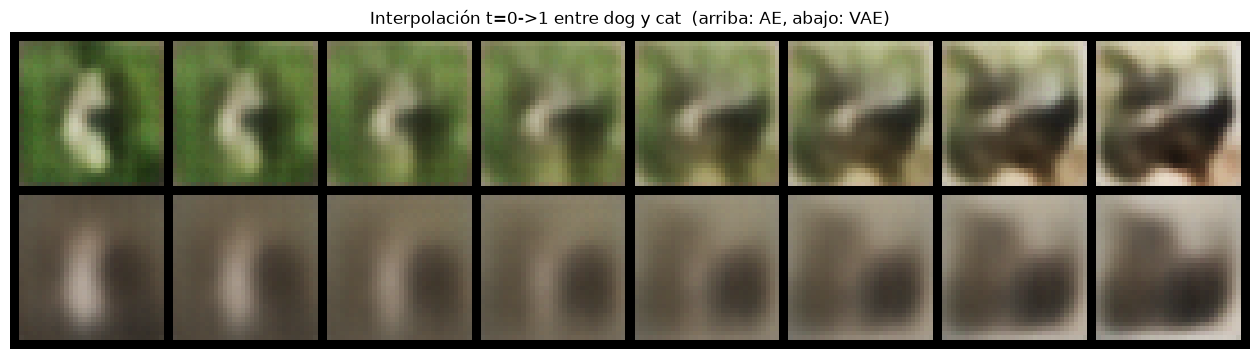

Suavidad de la interpolación (menor = más gradual): AE=0.0369  VAE=0.0314


In [19]:
@torch.no_grad()
def pick_two_images(loader, want_different_classes=True):
    x, y = next(iter(loader))
    if want_different_classes and len(set(y.tolist())) > 1:
        idx_a = (y == y[0]).nonzero()[0].item()
        idx_b = (y != y[idx_a]).nonzero()[0].item()
    else:
        idx_a, idx_b = 0, 1
    return x[idx_a:idx_a + 1], x[idx_b:idx_b + 1], y[idx_a].item(), y[idx_b].item()


x_A, x_B, y_A, y_B = pick_two_images(test_loader)
print(f"Imagen A: clase = {CLASS_NAMES[y_A]}   |   Imagen B: clase = {CLASS_NAMES[y_B]}")

x_A, x_B = x_A.to(device), x_B.to(device)
T_STEPS = 8
ts = torch.linspace(0, 1, T_STEPS)


@torch.no_grad()
def interpolate_ae(model, x_a, x_b, ts):
    z_a = model.encoder(x_a)
    z_b = model.encoder(x_b)
    frames = []
    for t in ts:
        z_t = (1 - t) * z_a + t * z_b
        frames.append(model.decoder(z_t))
    return torch.cat(frames, dim=0)


@torch.no_grad()
def interpolate_vae(model, x_a, x_b, ts):
    mu_a, _ = model.encoder(x_a)
    mu_b, _ = model.encoder(x_b)
    frames = []
    for t in ts:
        z_t = (1 - t) * mu_a + t * mu_b
        frames.append(model.decoder(z_t))
    return torch.cat(frames, dim=0)


ae_interp = interpolate_ae(ae_model, x_A, x_B, ts).cpu()
vae_interp = interpolate_vae(vae_model, x_A, x_B, ts).cpu()

rows = torch.cat([ae_interp, vae_interp], dim=0)
grid = make_grid(rows, nrow=T_STEPS, padding=2)
plt.figure(figsize=(2.0 * T_STEPS, 5))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title(f"Interpolación t=0->1 entre {CLASS_NAMES[y_A]} y {CLASS_NAMES[y_B]}  (arriba: AE, abajo: VAE)")
plt.show()

# Proxy cuantitativo de "suavidad": diferencia promedio entre frames consecutivos.
# Un valor más bajo sugiere una transición más gradual/suave.
def interpolation_smoothness(frames):
    diffs = (frames[1:] - frames[:-1]).abs().mean().item()
    return diffs


ae_smoothness = interpolation_smoothness(ae_interp)
vae_smoothness = interpolation_smoothness(vae_interp)
print(f"Suavidad de la interpolación (menor = más gradual): AE={ae_smoothness:.4f}  VAE={vae_smoothness:.4f}")

**Qué esperar:** en el AE, los pasos intermedios de la interpolación suelen verse borrosos o con artefactos poco realistas, porque nada obliga a que el espacio entre dos puntos del latente decodifique a imágenes plausibles. En el VAE, gracias a la regularización KL hacia `N(0,I)`, la región entre `mu_A` y `mu_B` está más densamente poblada por el prior, así que la interpolación suele transicionar de forma más gradual y realista.

## 6. Comparación final

In [20]:
# La tabla se construye a partir de las métricas ya calculadas arriba
# (no de números fijos), así que refleja tu corrida real.

noise_sigma_for_robustness = NOISE_LEVELS_EVAL[-1]  # el nivel de ruido más alto evaluado
ae_high_noise = robustness["AE"][-1]
dae_high_noise = robustness["DAE"][-1]

comparison_table = pd.DataFrame({
    "Propiedad": [
        "Error de reconstrucción (test, entrada limpia)",
        f"Robustez a ruido (test loss, sigma={noise_sigma_for_robustness})",
        "Organización del latente (silhouette cat/dog)",
        "Suavidad de interpolación (menor = mejor)",
        "Genera muestras nuevas realistas (z ~ N(0,I))",
    ],
    "AE": [
        f"{ae_test_loss:.4f}",
        f"{ae_high_noise:.4f}",
        f"{sil_ae:.3f}",
        f"{ae_smoothness:.4f}",
        "No",
    ],
    "DAE": [
        f"{dae_test_loss_clean:.4f}",
        f"{dae_high_noise:.4f}",
        f"{sil_dae:.3f}",
        "N/A (no se interpola el DAE arriba)",
        "No",
    ],
    "VAE": [
        f"{vae_test_recon:.4f}  (+ KL={vae_test_kl:.4f})",
        "N/A (no entrenado con ruido de entrada)",
        f"{sil_vae:.3f}",
        f"{vae_smoothness:.4f}",
        "Sí",
    ],
})

comparison_table

,Propiedad,AE,DAE,VAE
0,"Error de reconstrucción (test, entrada limpia)",20.4293,26.7524,55.2176 (+ KL=21.0284)
1,"Robustez a ruido (test loss, sigma=0.8)",87.2022,75.3044,N/A (no entrenado con ruido de entrada)
2,Organización del latente (silhouette cat/dog),0.002,0.003,0.002
3,Suavidad de interpolación (menor = mejor),0.0369,N/A (no se interpola el DAE arriba),0.0314
4,"Genera muestras nuevas realistas (z ~ N(0,I))",No,No,Sí


## Preguntas finales

In [21]:
# Las respuestas de abajo se arman a partir de las metricas YA calculadas
# en las secciones anteriores (nunca numeros fijos) y se muestran como
# Markdown real (Markdown(...) + display), para que el texto se lea como
# un reporte y siempre refleje tu corrida real.

losses_clean = {"AE": ae_test_loss, "DAE": dae_test_loss_clean, "VAE": vae_test_recon}
best_recon = min(losses_clean, key=losses_clean.get)
mas_robusto = "DAE" if dae_high_noise < ae_high_noise else "AE"

respuestas_md = "\n\n".join([
    "**1. ¿Qué modelo obtiene mejores reconstrucciones?**",

    f'Losses de reconstrucción en test (entrada limpia, más bajo = mejor): AE = `{losses_clean["AE"]:.4f}`, '
    f'DAE = `{losses_clean["DAE"]:.4f}`, VAE = `{losses_clean["VAE"]:.4f}`. En esta corrida, **{best_recon}** '
    f'obtiene la mejor reconstrucción. Es lo esperado: el AE optimiza reconstrucción pura, sin restricciones '
    f'adicionales; el DAE resuelve una tarea más difícil (reconstruir limpio a partir de entrada corrupta); '
    f'y el VAE reparte capacidad de la red entre reconstruir y regularizar el espacio latente (término KL), '
    f'por lo que normalmente reconstruye algo peor que un AE puro, a cambio de un latente más útil.',

    "**2. ¿Qué modelo es más robusto al ruido?**",

    f'Loss de reconstrucción con sigma = `{noise_sigma_for_robustness}`: AE = `{ae_high_noise:.4f}`, '
    f'DAE = `{dae_high_noise:.4f}`. El más robusto en esta corrida es el **{mas_robusto}**. Tiene sentido que '
    f'sea el DAE: es el único que ve ruido gaussiano (nuevo en cada batch) durante el entrenamiento, así que '
    f'aprende a ignorarlo; el AE nunca ve entradas ruidosas al entrenar, por lo que su error crece más rápido '
    f'conforme sube `sigma` (curva de la sección 2).',

    "**3. ¿Cómo cambia el espacio latente entre AE, DAE y VAE?**",

    f'Silhouette score (cat vs dog, más alto = clases más separadas) en el latente crudo: AE = `{sil_ae:.3f}`, '
    f'DAE = `{sil_dae:.3f}`, VAE = `{sil_vae:.3f}`. Ninguno de los tres modelos usa las etiquetas para entrenar, '
    f'así que esta separación es un subproducto de la tarea de reconstrucción. El AE organiza el latente solo '
    f'en función de qué tan bien reconstruye cada imagen, lo que puede dejar huecos y regiones nunca visitadas. '
    f'El DAE, al tener que ser invariante a perturbaciones, tiende a agrupar entre sí distintas versiones '
    f'ruidosas de una misma imagen, generando representaciones algo más compactas y robustas. El VAE, por el '
    f'término KL, empuja explícitamente `q(z|x)` hacia `N(0,I)`: el resultado suele ser un latente más continuo '
    f'y sin huecos grandes, aunque eso puede venir con algo más de solapamiento entre clases que en un AE muy '
    f'ajustado a los datos.',

    "**4. ¿Por qué el VAE puede generar nuevas muestras utilizando `z ~ N(0,I)`?**",

    'Porque el término KL de la función de pérdida obliga a que la distribución posterior aproximada `q(z|x)` '
    'de cada dato se parezca a la prior `N(0,I)`. Como resultado, la distribución agregada de posteriores sobre '
    'todo el dataset también se aproxima a `N(0,I)`, así que un `z` muestreado directamente de la prior cae en '
    'una región del espacio latente que el decoder ya aprendió a decodificar durante el entrenamiento. En AE y '
    'DAE no existe esa restricción: el encoder puede mapear los datos a cualquier región del espacio sin '
    'penalización, dejando huecos que el decoder nunca vio, por eso muestrear `z ~ N(0,I)` en un AE suele '
    'producir imágenes con artefactos (sección 3).',

    "**5. ¿Qué trade-off introduce el término KL del VAE?**",

    f'En esta corrida, el VAE tiene recon = `{vae_test_recon:.4f}` y KL = `{vae_test_kl:.4f}` '
    f'(total = `{vae_test_recon + vae_test_kl:.4f}`). El término KL mejora la estructura y generatividad del '
    f'latente (continuidad, ausencia de huecos grandes, posibilidad real de muestrear), pero compite '
    f'directamente con el término de reconstrucción. Más peso relativo en KL (o un prior más restrictivo) '
    f'tiende a producir reconstrucciones más borrosas o con menos detalle, y en casos extremos puede llevar a '
    f'colapso posterior, donde el modelo prácticamente ignora `z`. Es, en el fondo, un balance explícito entre '
    f'fidelidad de reconstrucción y regularidad/generatividad del espacio latente.',

    "**6. ¿Qué modelo elegirías para reconstrucción, denoising y generación?**",

    '- Reconstrucción pura / compresión: **AE** — no necesita pagar el costo de robustez a ruido ni de '
    'regularización KL si el objetivo es solo reconstruir bien.\n'
    '- Denoising / representaciones robustas a corrupción de entrada: **DAE** — es el único entrenado '
    'explícitamente para esa tarea.\n'
    '- Generación de muestras nuevas, interpolación o muestreo del espacio latente: **VAE** — es el único cuyo '
    'latente sigue una distribución conocida (`N(0,I)`) de la que se puede muestrear directamente.',
])

display(Markdown(respuestas_md))

**1. ¿Qué modelo obtiene mejores reconstrucciones?**

Losses de reconstrucción en test (entrada limpia, más bajo = mejor): AE = `20.4293`, DAE = `26.7524`, VAE = `55.2176`. En esta corrida, **AE** obtiene la mejor reconstrucción. Es lo esperado: el AE optimiza reconstrucción pura, sin restricciones adicionales; el DAE resuelve una tarea más difícil (reconstruir limpio a partir de entrada corrupta); y el VAE reparte capacidad de la red entre reconstruir y regularizar el espacio latente (término KL), por lo que normalmente reconstruye algo peor que un AE puro, a cambio de un latente más útil.

**2. ¿Qué modelo es más robusto al ruido?**

Loss de reconstrucción con sigma = `0.8`: AE = `87.2022`, DAE = `75.3044`. El más robusto en esta corrida es el **DAE**. Tiene sentido que sea el DAE: es el único que ve ruido gaussiano (nuevo en cada batch) durante el entrenamiento, así que aprende a ignorarlo; el AE nunca ve entradas ruidosas al entrenar, por lo que su error crece más rápido conforme sube `sigma` (curva de la sección 2).

**3. ¿Cómo cambia el espacio latente entre AE, DAE y VAE?**

Silhouette score (cat vs dog, más alto = clases más separadas) en el latente crudo: AE = `0.002`, DAE = `0.003`, VAE = `0.002`. Ninguno de los tres modelos usa las etiquetas para entrenar, así que esta separación es un subproducto de la tarea de reconstrucción. El AE organiza el latente solo en función de qué tan bien reconstruye cada imagen, lo que puede dejar huecos y regiones nunca visitadas. El DAE, al tener que ser invariante a perturbaciones, tiende a agrupar entre sí distintas versiones ruidosas de una misma imagen, generando representaciones algo más compactas y robustas. El VAE, por el término KL, empuja explícitamente `q(z|x)` hacia `N(0,I)`: el resultado suele ser un latente más continuo y sin huecos grandes, aunque eso puede venir con algo más de solapamiento entre clases que en un AE muy ajustado a los datos.

**4. ¿Por qué el VAE puede generar nuevas muestras utilizando `z ~ N(0,I)`?**

Porque el término KL de la función de pérdida obliga a que la distribución posterior aproximada `q(z|x)` de cada dato se parezca a la prior `N(0,I)`. Como resultado, la distribución agregada de posteriores sobre todo el dataset también se aproxima a `N(0,I)`, así que un `z` muestreado directamente de la prior cae en una región del espacio latente que el decoder ya aprendió a decodificar durante el entrenamiento. En AE y DAE no existe esa restricción: el encoder puede mapear los datos a cualquier región del espacio sin penalización, dejando huecos que el decoder nunca vio, por eso muestrear `z ~ N(0,I)` en un AE suele producir imágenes con artefactos (sección 3).

**5. ¿Qué trade-off introduce el término KL del VAE?**

En esta corrida, el VAE tiene recon = `55.2176` y KL = `21.0284` (total = `76.2461`). El término KL mejora la estructura y generatividad del latente (continuidad, ausencia de huecos grandes, posibilidad real de muestrear), pero compite directamente con el término de reconstrucción. Más peso relativo en KL (o un prior más restrictivo) tiende a producir reconstrucciones más borrosas o con menos detalle, y en casos extremos puede llevar a colapso posterior, donde el modelo prácticamente ignora `z`. Es, en el fondo, un balance explícito entre fidelidad de reconstrucción y regularidad/generatividad del espacio latente.

**6. ¿Qué modelo elegirías para reconstrucción, denoising y generación?**

- Reconstrucción pura / compresión: **AE** — no necesita pagar el costo de robustez a ruido ni de regularización KL si el objetivo es solo reconstruir bien.
- Denoising / representaciones robustas a corrupción de entrada: **DAE** — es el único entrenado explícitamente para esa tarea.
- Generación de muestras nuevas, interpolación o muestreo del espacio latente: **VAE** — es el único cuyo latente sigue una distribución conocida (`N(0,I)`) de la que se puede muestrear directamente.

## Conclusiones breves

- Los tres modelos comparten arquitectura, dimensión latente, batch size, optimizador y número de épocas, así que las diferencias observadas en las celdas anteriores provienen de la función objetivo, no de la capacidad del modelo.
- El AE es el punto de referencia de "mejor caso" para reconstrucción pura, pero no ofrece ni robustez a ruido ni capacidad de generación.
- El DAE sacrifica algo de fidelidad de reconstrucción en entradas limpias a cambio de robustez explícita al ruido — visible en la curva de la sección 2, donde su loss crece más lento que el del AE a medida que sube `sigma`.
- El VAE es el único de los tres capaz de generar muestras nuevas y razonables muestreando directamente `z ~ N(0,I)`, gracias a la regularización KL; a cambio, su reconstrucción y separación de clases suelen ser algo peores que las del AE.
- La elección de modelo depende de la tarea: reconstrucción/compresión → AE; robustez a ruido/corrupción → DAE; generación e interpolación en el espacio latente → VAE.

*(Estas conclusiones están escritas para razonar correctamente sobre el comportamiento esperado de cada modelo; confírmalas contra los números y gráficas que produzca tu propia corrida, ya que dependen de la semilla, los hiperparámetros y el subconjunto de datos usado.)*